In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset (make sure file path is correct)
dataset = pd.read_csv(r'C:\Users\revat\Downloads\archive\Social_Network_Ads.csv')

# Display first few rows
print(dataset.head())\

# Select features and target
X = dataset.iloc[:, [2, 3]].values   # Age, EstimatedSalary
y = dataset.iloc[:, 4].values        # Purchased

# Split dataset into training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Train Logistic Regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict test results
y_pred = model.predict(X_test)

print("Predicted values:\n", y_pred)

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
Predicted values:
 [0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 1 0 1 1 1 1 0 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1]


In [5]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

# Extract values
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("\nTP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)

# Metrics calculation
accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = 1 - accuracy
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("\nAccuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

Confusion Matrix:
 [[65  3]
 [ 8 24]]

TP: 24
FP: 3
TN: 65
FN: 8

Accuracy: 0.89
Error Rate: 0.10999999999999999
Precision: 0.8888888888888888
Recall: 0.75


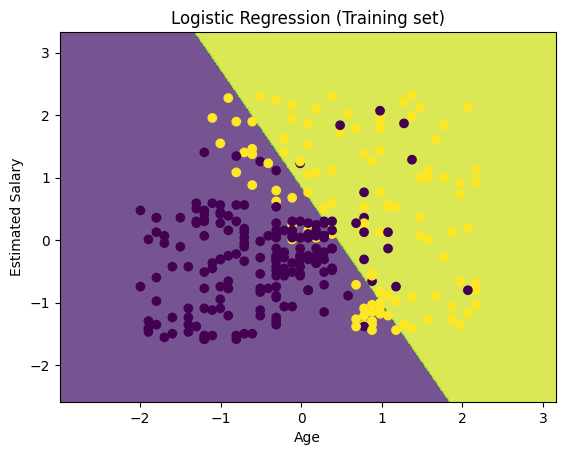

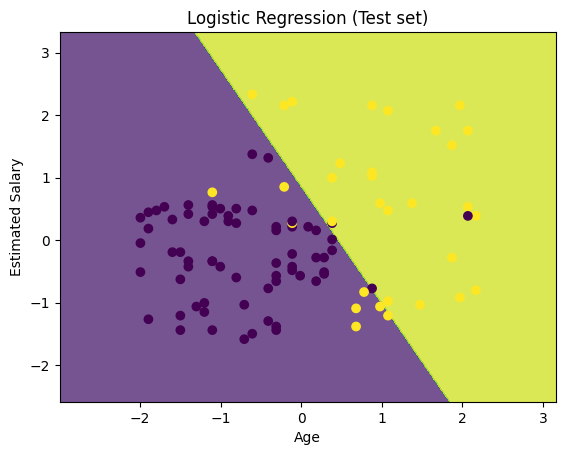

In [6]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

# ===== TRAINING SET GRAPH =====
X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

plt.figure()
plt.contourf(
    X1, X2,
    model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75
)

plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set)
plt.title('Logistic Regression (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.show()


# ===== TEST SET GRAPH =====
X_set, y_set = X_test, y_test

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

plt.figure()
plt.contourf(
    X1, X2,
    model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75
)

plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set)
plt.title('Logistic Regression (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.show()